<a href="https://colab.research.google.com/github/erlanggajuni45/book-recommendation-system/blob/main/Book_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Book Recommendation System**

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

set visual theme

In [ ]:
sns.set_theme(style="whitegrid")

download dataset via GitHub

In [ ]:
books_url = 'https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/books.csv'
ratings_url = 'https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv'

books = pd.read_csv(books_url)
ratings = pd.read_csv(ratings_url)

menampilkan informasi tentang dataset books

In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

informasi tentang sebaran data setiap kolomnya untuk dataset books

In [ ]:
books.describe(include='all')

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9300,9.415000e+03,10000,9979.000000,9415,...,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000,10000
unique,NaN,NaN,NaN,NaN,NaN,9300,NaN,4664,NaN,9274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6669,6669
top,NaN,NaN,NaN,NaN,NaN,375700455,NaN,Stephen King,NaN,The Gift,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
freq,NaN,NaN,NaN,NaN,NaN,1,NaN,60,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3332,3332
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,NaN,9.755044e+12,NaN,1981.987674,NaN,...,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04,NaN,NaN
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,NaN,4.428619e+11,NaN,152.576665,NaN,...,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04,NaN,NaN
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,NaN,1.951703e+08,NaN,-1750.000000,NaN,...,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02,NaN,NaN
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,NaN,9.780316e+12,NaN,1990.000000,NaN,...,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03,NaN,NaN
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,NaN,9.780452e+12,NaN,2004.000000,NaN,...,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03,NaN,NaN
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,NaN,9.780831e+12,NaN,2011.000000,NaN,...,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04,NaN,NaN


menampilkan informasi tentang dataset ratings

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


informasi tentang sebaran data setiap kolomnya untuk dataset ratings

In [ ]:
ratings.describe(include='all')

,user_id,book_id,rating
count,5.976479e+06,5.976479e+06,5.976479e+06
mean,2.622446e+04,2.006477e+03,3.919866e+00
std,1.541323e+04,2.468499e+03,9.910868e-01
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.281300e+04,1.980000e+02,3.000000e+00
50%,2.593800e+04,8.850000e+02,4.000000e+00
75%,3.950900e+04,2.973000e+03,5.000000e+00
max,5.342400e+04,1.000000e+04,5.000000e+00


## **Exploratory Data Analysis (EDA)**

Pengecekan missing value

In [ ]:
print("=== Missing Value pada Books ===")
books.isnull().sum()[books.isnull().sum() > 0]

=== Missing Value pada Books ===


,0
isbn,700
isbn13,585
original_publication_year,21
original_title,585
language_code,1084


In [ ]:
print(f'\nJumlah duplikat pada books: {books.duplicated().sum()}')


Jumlah duplikat pada books: 0


In [ ]:
print("=== Missing Value pada Ratings ===")
ratings.isnull().sum()[ratings.isnull().sum() > 0]

=== Missing Value pada Ratings ===


,0


In [ ]:
print(f'\nJumlah duplikat pada ratings: {ratings.duplicated().sum()}')


Jumlah duplikat pada ratings: 0


Visualisasi top 10 penulis dengan buku terbanyak

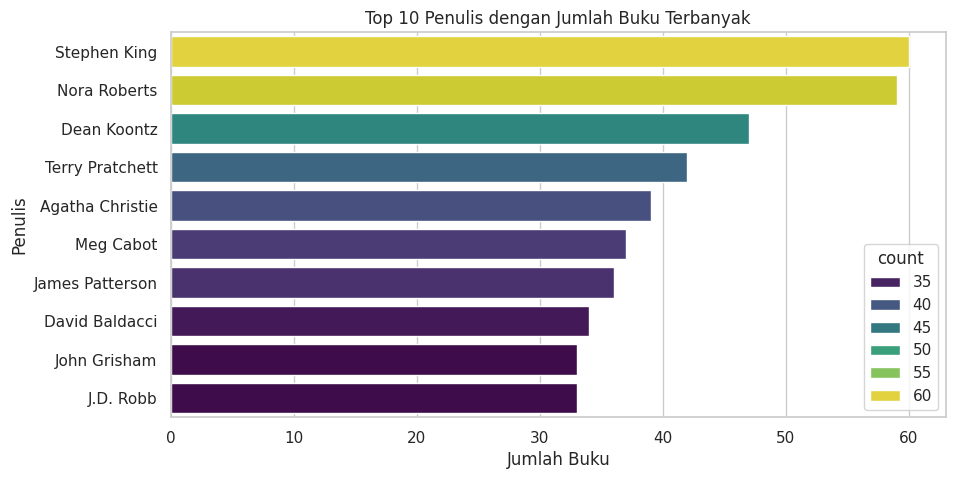

In [ ]:
top_authors = books['authors'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis', hue=top_authors)
plt.title('Top 10 Penulis dengan Jumlah Buku Terbanyak')
plt.xlabel('Jumlah Buku')
plt.ylabel('Penulis')
plt.show()

Visualisasi top 10 buku dengan rating terbanyak

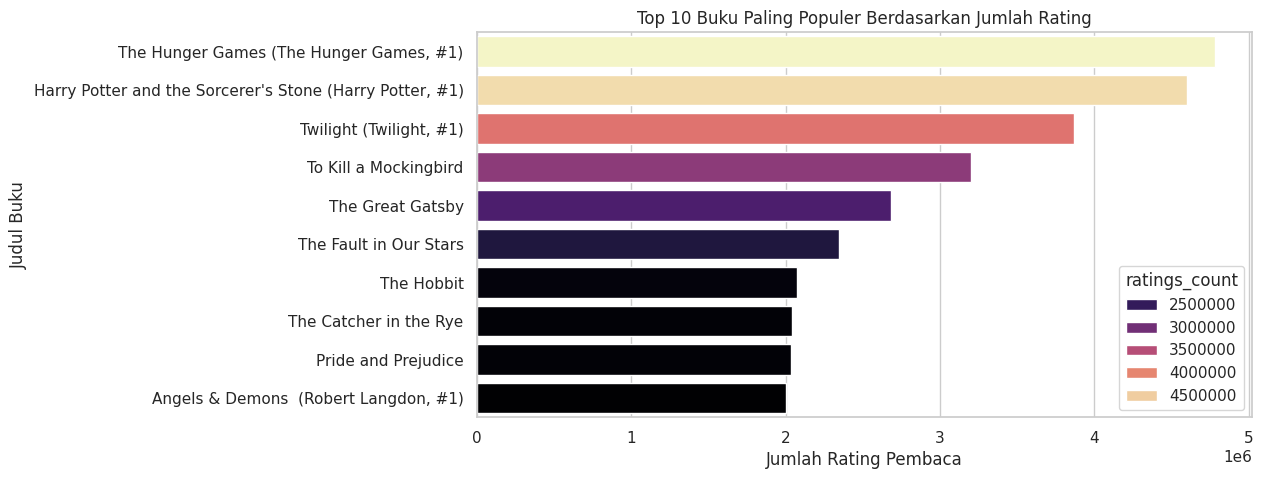

In [ ]:
top_rated_books = books.sort_values(by='ratings_count', ascending=False)[['title', 'ratings_count']].head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='ratings_count', y='title', data=top_rated_books, palette='magma', hue='ratings_count')
plt.title('Top 10 Buku Paling Populer Berdasarkan Jumlah Rating')
plt.xlabel('Jumlah Rating Pembaca')
plt.ylabel('Judul Buku')
plt.show()

Distribusi skor rating pengguna

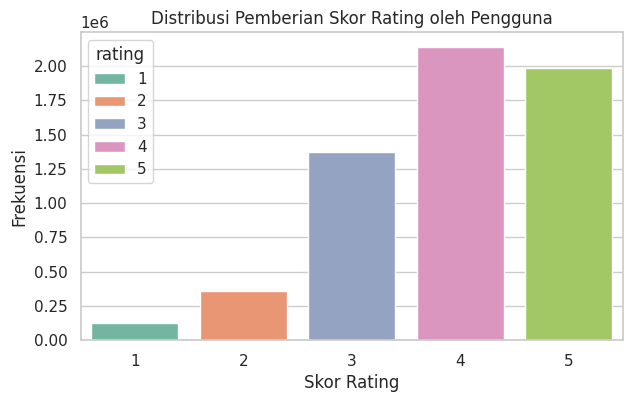

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='rating', data=ratings, palette='Set2', hue='rating')
plt.title('Distribusi Pemberian Skor Rating oleh Pengguna')
plt.xlabel('Skor Rating')
plt.ylabel('Frekuensi')
plt.show()

distribusi rata-rata rating buku

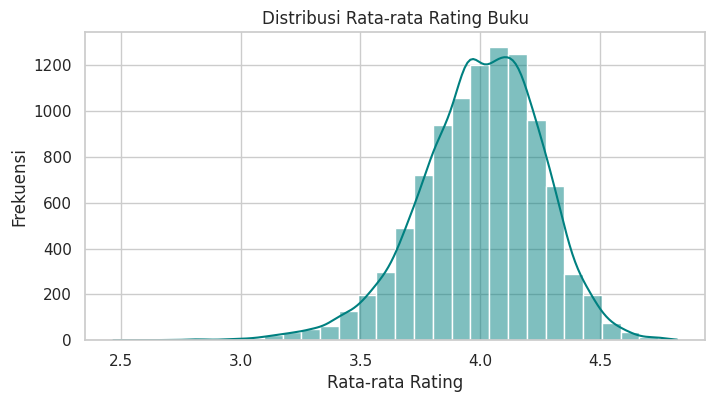

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(books['average_rating'], bins=30, kde=True, color='teal')
plt.title('Distribusi Rata-rata Rating Buku')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Frekuensi')
plt.show()

## **Data Preparation**

### Untuk Content-Based Filtering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

memilih kolom penting dan menghapus baris dengan judul atau penulis bernilai null

In [ ]:
df_cb = books[['book_id', 'title', 'authors', 'average_rating']].dropna().copy()
df_cb.drop_duplicates(subset=['title'], inplace=True)
df_cb

,book_id,title,authors,average_rating
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,3.57
3,4,To Kill a Mockingbird,Harper Lee,4.25
4,5,The Great Gatsby,F. Scott Fitzgerald,3.89
...,...,...,...,...
9995,9996,"Bayou Moon (The Edge, #2)",Ilona Andrews,4.09
9996,9997,"Means of Ascent (The Years of Lyndon Johnson, #2)",Robert A. Caro,4.25
9997,9998,The Mauritius Command,Patrick O'Brian,4.35
9998,9999,Cinderella Ate My Daughter: Dispatches from th...,Peggy Orenstein,3.65


membuat representasi fitur gabungan

In [ ]:
df_cb['content_features'] = df_cb['title'] + ' ' + df_cb['authors']
df_cb.shape

(9964, 5)

Ekstraksi fitur menggunakan TF-IDF Vectorizer

In [ ]:
tf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tf.fit_transform(df_cb['content_features'])
tfidf_matrix.shape

(9964, 14219)

### Untuk Collaborative Filtering

mengambil sampel 100.000 data rating secara acak untuk efisiensi komputasi

In [ ]:
ratings_sample = ratings.sample(n=100000, random_state=42).copy()

encoding user_id menjadi indeks integer unik

In [ ]:
user_ids = ratings_sample['user_id'].unique().tolist()
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
ratings_sample['user'] = ratings_sample['user_id'].map(user_to_user_encoded)

encoding book_id menjadi indeks integer unik

In [ ]:
books_ids = ratings_sample['book_id'].unique().tolist()
book_to_book_encoded = {x: i for i, x in enumerate(books_ids)}
book_encoded_to_book = {i: x for i, x in enumerate(books_ids)}
ratings_sample['book'] = ratings_sample['book_id'].map(book_to_book_encoded)

memunculkan data unik user dan book

In [ ]:
num_users = len(user_to_user_encoded)
num_books = len(book_to_book_encoded)
print(f'Jumlah sampel user unik: {num_users}')
print(f'Jumlah sampel buku unik: {num_books}')

Jumlah sampel user unik: 44477
Jumlah sampel buku unik: 9521


normalisasi nilai rating ke rentang 0 hingga 1

In [ ]:
min_rating = ratings_sample['rating'].min()
max_rating = ratings_sample['rating'].max()
ratings_sample['rating_norm'] = ratings_sample['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating))

membagi data latih dan validasi 80/20

In [ ]:
ratings_sample = ratings_sample.sample(frac=1, random_state=42)
x = ratings_sample[['user', 'book']].values
y = ratings_sample['rating_norm'].values

train_indices = int(0.8 * ratings_sample.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:],
)

print(f"Dimensi x_train: {x_train.shape}, Dimensi x_val: {x_val.shape}")

Dimensi x_train: (80000, 2), Dimensi x_val: (20000, 2)


## **Modelling**

### Model Content-Based Filtering

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

Menghitung Cosine Similarity antar buku

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

Membuat mapping indeks judul buku

In [ ]:
indices = pd.Series(df_cb.index, index=df_cb['title']).drop_duplicates()

fungsi Top-N Recommendation berbasis konten

In [ ]:
def get_content_based_recommendations(title, cosine_sim=cosine_sim, top_n=10):
  if title not in indices:
    return f"Buku '{title}' tidak ditemukan."

  idx = indices[title]
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1:top_n+1]

  book_indices = [i[0] for i in sim_scores]

  rec_df = df_cb.iloc[book_indices][['title', 'authors', 'average_rating']].copy()
  rec_df['similarity_score'] = [i[1] for i in sim_scores]
  return rec_df

uji coba rekomendasi untuk satu judul buku tertentu

In [ ]:
sample_book = 'The Hunger Games (The Hunger Games, #1)'
print(f"Top-10 Rekomendasi Buku Mirip dengan: '{sample_book}'\n")
get_content_based_recommendations(sample_book, top_n=10)

Top-10 Rekomendasi Buku Mirip dengan: 'The Hunger Games (The Hunger Games, #1)'



,title,authors,average_rating,similarity_score
506,The Hunger Games Trilogy Boxset (The Hunger Ga...,Suzanne Collins,4.49,0.912934
16,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30,0.807468
19,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,4.03,0.797473
6223,The World of the Hunger Games (Hunger Games Tr...,Kate Egan,4.48,0.771634
1354,The Hunger Games Tribute Guide,Emily Seife,4.40,0.497202
716,The Hunger Games: Official Illustrated Movie C...,Kate Egan,4.51,0.445242
1819,"Hunger (Gone, #2)",Michael Grant,4.02,0.370337
3114,A Hunger Like No Other (Immortals After Dark #2),Kresley Cole,4.21,0.292212
5945,"The Quillan Games (Pendragon, #7)",D.J. MacHale,4.19,0.284231
4460,"Nemesis Games (The Expanse, #5)",James S.A. Corey,4.37,0.280613


### Model Collaborative Filtering

import library yang diperlukan

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

definisikan arsitektur model RecommenderNet

In [ ]:
class RecommenderNet(keras.Model):
  def __init__(self, num_users, num_books, embedding_size, **kwargs):
    super(RecommenderNet, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_books = num_books
    self.embedding_size = embedding_size

    # User Embedding & Bias
    self.user_embedding = layers.Embedding(
        num_users,
        embedding_size,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(1e-6)
    )
    self.user_bias = layers.Embedding(num_users, 1)

    # Book Embedding & Bias
    self.book_embedding = layers.Embedding(
        num_books,
        embedding_size,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(1e-6)
    )
    self.book_bias = layers.Embedding(num_books, 1)

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:, 0])
    user_bias = self.user_bias(inputs[:, 0])
    book_vector = self.book_embedding(inputs[:, 1])
    book_bias = self.book_bias(inputs[:, 1])

    # Dot product antara vektor user dan buku
    dot_user_book = tf.tensordot(user_vector, book_vector, 2)

    # Menjumlahkan dot product dengan bias
    x = dot_user_book + user_bias + book_bias

    # Aktivasi sigmoid untuk membatasi output pada skala [0,1]
    return tf.nn.sigmoid(x)

Inisialisasi dan Kompilasi Model

In [ ]:
model = RecommenderNet(num_users, num_books, embedding_size=50)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='root_mean_squared_error')]
)

training model

In [ ]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.6760 - root_mean_squared_error: 0.3242 - val_loss: 0.6485 - val_root_mean_squared_error: 0.3030
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.5835 - root_mean_squared_error: 0.2457 - val_loss: 0.6590 - val_root_mean_squared_error: 0.3114
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5749 - root_mean_squared_error: 0.2387 - val_loss: 0.6527 - val_root_mean_squared_error: 0.3058
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5737 - root_mean_squared_error: 0.2369 - val_loss: 0.6544 - val_root_mean_squared_error: 0.3064
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.5789 - root_mean_squared_error: 0.2402 - val_loss: 0.6547 - val_root_mean_squared_error: 0.3057
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5878 - root_mean_squared_error: 0.2456 - val_loss: 0.6556 - val_root_mean_squared_error: 0.3057
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━

## **Evaluasi**

Visualisasi Metrik Evaluasi RMSE & Loss

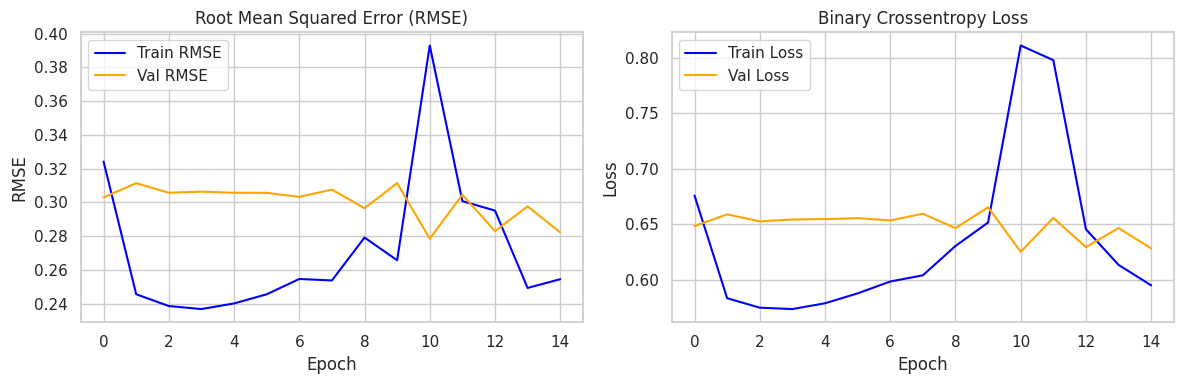

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE', color='blue')
plt.plot(history.history['val_root_mean_squared_error'], label ='Val RMSE', color='orange')
plt.title('Root Mean Squared Error (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Binary Crossentropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Fungsi rekomendasi buku untuk spesifik user

In [ ]:
def get_collaborative_recommendations(user_id, top_n=10):
  if user_id not in user_to_user_encoded:
    return f"User dengan ID '{user_id}' tidak ditemukan."

  user_encoded = user_to_user_encoded[user_id]

  books_read_by_user = ratings_sample[ratings_sample['user_id'] == user_id]

  books_not_read = [b for b in book_to_book_encoded.keys() if b not in books_read_by_user['book_id'].values]
  books_not_read_encoded = [book_to_book_encoded[b] for b in books_not_read]

  user_book_array = np.hstack(
      ([[user_encoded]] * len(books_not_read_encoded), np.array(books_not_read_encoded).reshape(-1,1))
  )

  ratings_pred = model.predict(user_book_array, verbose=0).flatten()

  top_indices = ratings_pred.argsort()[-top_n:][::-1]
  recommended_book_ids = [book_encoded_to_book[books_not_read_encoded[i]] for i in top_indices]

  rec_books = books[books['book_id'].isin(recommended_book_ids)][['title', 'authors', 'average_rating']]
  return rec_books

uji rekomendasi personal untuk sampel user

In [ ]:
sample_user_id = ratings_sample['user_id'].iloc[0]
print(f"Top-10 Rekomendasi Buku untuk User ID: {sample_user_id}\n")
get_collaborative_recommendations(sample_user_id, top_n=10)

Top-10 Rekomendasi Buku untuk User ID: 43140



,title,authors,average_rating
23,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPré",4.53
24,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",4.61
143,"Unbroken: A World War II Story of Survival, Re...",Laura Hillenbrand,4.40
290,Cutting for Stone,Abraham Verghese,4.28
421,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,4.74
728,"Hyperion (Hyperion Cantos, #1)",Dan Simmons,4.21
739,"The Little House Collection (Little House, #1-9)","Laura Ingalls Wilder, Garth Williams",4.33
861,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.77
957,The Complete Anne of Green Gables Boxed Set (A...,L.M. Montgomery,4.42
3081,Brief Lives (The Sandman #7),"Neil Gaiman, Jill Thompson, Vince Locke, Peter...",4.55


Evaluasi Content-Based Filtering menggunakan Precision@K

Menghitung proporsi rekomendasi yang relevan

In [ ]:
def evaluate_precision_at_k(recommendations_df, relevant_keywords=["hunger", "suzanne collins"], k=10):
  top_k = recommendations_df.head(k)

  relevant_items = top_k.apply(lambda row: 1 if any(kw in row['title'].lower()
    or kw in row['authors'].lower() for kw in relevant_keywords) else 0, axis=1).sum()
  precision = relevant_items / k
  return precision

Uji Precision@10 pada sampel

In [ ]:
sample_recs = get_content_based_recommendations(sample_book, top_n=10)
precision_score = evaluate_precision_at_k(sample_recs, relevant_keywords=["hunger", "suzanne collins"], k=10)

print(f"Precision@10 untuk rekomendasi {sample_book}: {precision_score * 100:.1f}%")

Precision@10 untuk rekomendasi The Hunger Games (The Hunger Games, #1): 80.0%
